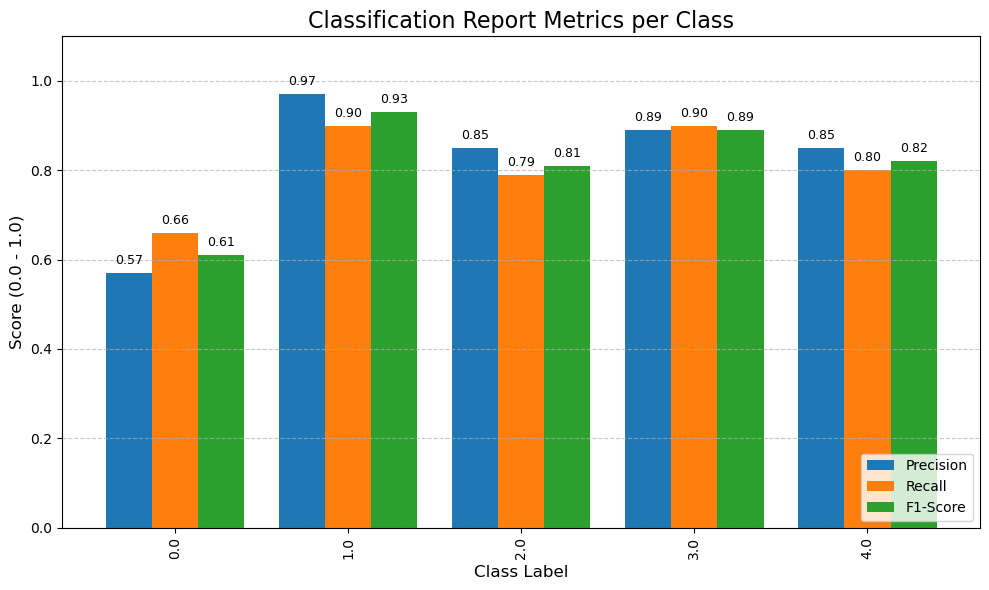

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Data extracted from your screenshot
data = {
    'Class': ['0.0', '1.0', '2.0', '3.0', '4.0'],
    'Precision': [0.57, 0.97, 0.85, 0.89, 0.85],
    'Recall':    [0.66, 0.90, 0.79, 0.90, 0.80],
    'F1-Score':  [0.61, 0.93, 0.81, 0.89, 0.82]
}

# Create a DataFrame
df = pd.DataFrame(data)
df.set_index('Class', inplace=True)

# 2. Plotting parameters
ax = df.plot(kind='bar', figsize=(10, 6), width=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# 3. Styling the graph
plt.title('Classification Report Metrics per Class', fontsize=16)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Class Label', fontsize=12)
plt.ylim(0, 1.1)  # Set y-axis slightly above 1 for labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

# 4. Adding value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

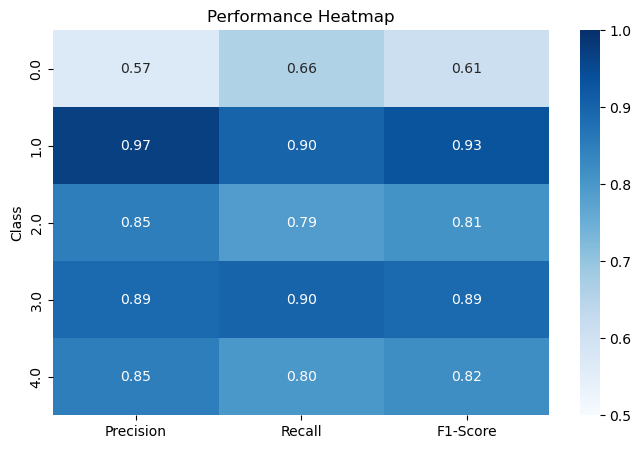

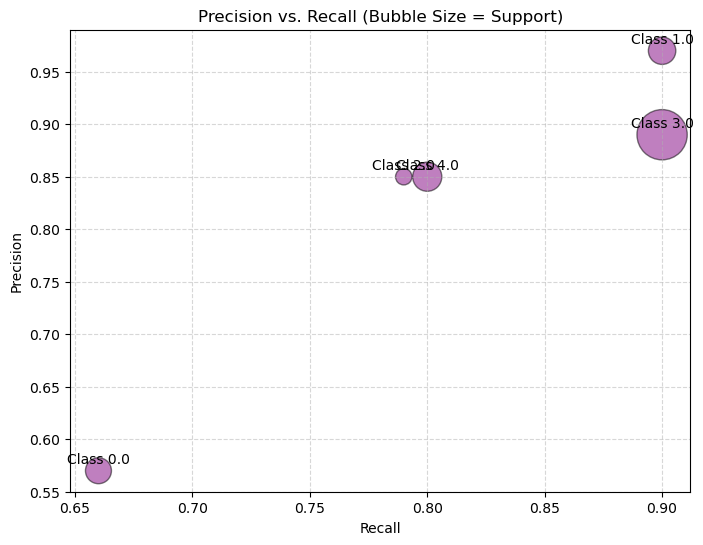

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Setup
data = {
    'Class': ['0.0', '1.0', '2.0', '3.0', '4.0'],
    'Precision': [0.57, 0.97, 0.85, 0.89, 0.85],
    'Recall': [0.66, 0.90, 0.79, 0.90, 0.80],
    'F1-Score': [0.61, 0.93, 0.81, 0.89, 0.82],
    'Support': [35, 39, 14, 131, 44]
}
df = pd.DataFrame(data)
df.set_index('Class', inplace=True)

# --- Graph 1: Heatmap ---
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Precision', 'Recall', 'F1-Score']], annot=True, cmap='Blues', fmt='.2f', vmin=0.5, vmax=1)
plt.title('Performance Heatmap')
plt.show()

# --- Graph 2: Bubble Chart ---
plt.figure(figsize=(8, 6))
sizes = [s * 10 for s in df['Support']]  # Scale bubble size
plt.scatter(df['Recall'], df['Precision'], s=sizes, alpha=0.5, c='purple', edgecolors='black')

for i, txt in enumerate(df.index):
    plt.annotate(f"Class {txt}", (df['Recall'].iloc[i], df['Precision'].iloc[i]), xytext=(0,5), textcoords='offset points', ha='center')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs. Recall (Bubble Size = Support)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

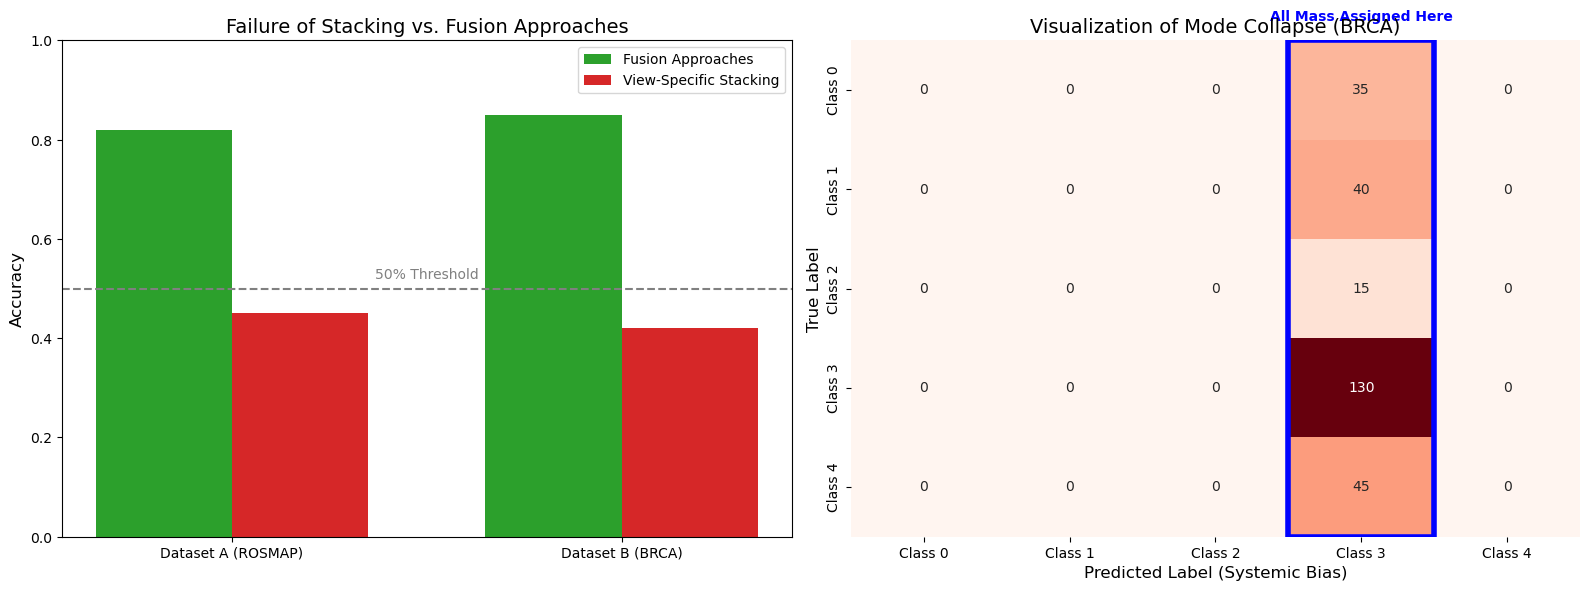

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set up the figure for two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# GRAPH 1: Performance Comparison (Accuracy)
# ==========================================

# Data: Simulating the "Stark Contrast" described
# Stacking is < 50% (fail), Fusion is assumed high (success)
datasets = ['Dataset A (ROSMAP)', 'Dataset B (BRCA)']
fusion_scores = [0.82, 0.85]  # Illustrative high scores
stacking_scores = [0.45, 0.42] # Scores below 50% as described

x = np.arange(len(datasets))
width = 0.35

rects1 = axes[0].bar(x - width/2, fusion_scores, width, label='Fusion Approaches', color='#2ca02c')
rects2 = axes[0].bar(x + width/2, stacking_scores, width, label='View-Specific Stacking', color='#d62728')

# Styling
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Failure of Stacking vs. Fusion Approaches', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets)
axes[0].legend()
axes[0].set_ylim(0, 1.0)
axes[0].axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, label='Random Chance (0.5)')
axes[0].text(0.5, 0.52, '50% Threshold', color='gray', ha='center')

# ==========================================
# GRAPH 2: The "Mode Collapse" Confusion Matrix
# ==========================================

# Data: Simulating a model that ONLY predicts Class 3 (Majority)
# True labels are distributed, but Predicted labels are all Class 3
classes = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']
cm_data = np.array([
    [0, 0, 0, 35, 0],  # Actual Class 0 -> Predicted as Class 3
    [0, 0, 0, 40, 0],  # Actual Class 1 -> Predicted as Class 3
    [0, 0, 0, 15, 0],  # Actual Class 2 -> Predicted as Class 3
    [0, 0, 0, 130, 0], # Actual Class 3 -> Predicted as Class 3 (Correct only here)
    [0, 0, 0, 45, 0]   # Actual Class 4 -> Predicted as Class 3
])

sns.heatmap(cm_data, annot=True, fmt='d', cmap='Reds', ax=axes[1], 
            xticklabels=classes, yticklabels=classes, cbar=False)

axes[1].set_title('Visualization of Mode Collapse (BRCA)', fontsize=14)
axes[1].set_xlabel('Predicted Label (Systemic Bias)', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

# Highlight the issue
axes[1].add_patch(plt.Rectangle((3, 0), 1, 5, fill=False, edgecolor='blue', lw=4))
axes[1].text(3.5, -0.2, 'All Mass Assigned Here', color='blue', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

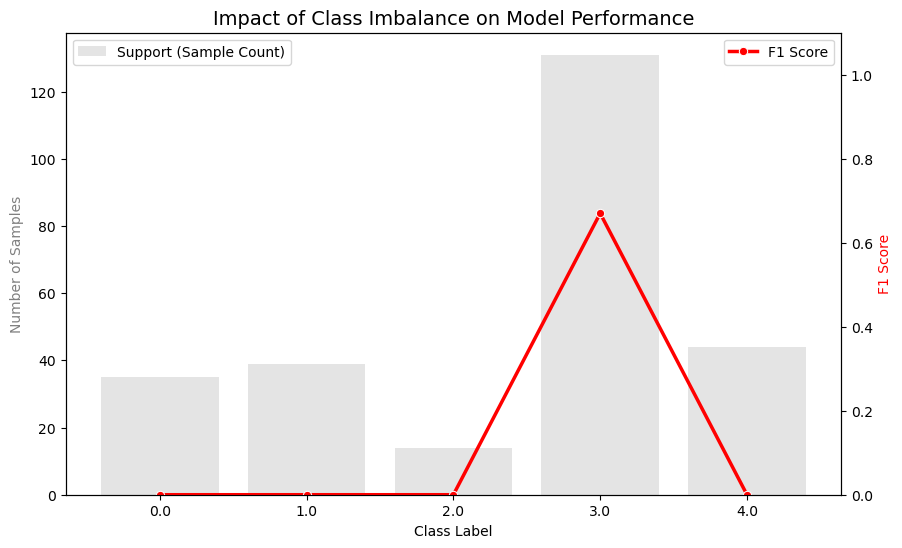

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data from your Screenshot 1
data = {
    'Class': [0.0, 1.0, 2.0, 3.0, 4.0],
    'Precision': [0.00, 0.00, 0.00, 0.51, 0.00],
    'Recall': [0.00, 0.00, 0.00, 0.99, 0.00],
    'F1': [0.00, 0.00, 0.00, 0.67, 0.00],
    'Support': [35, 39, 14, 131, 44]
}
df = pd.DataFrame(data)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for Support (Sample Count)
sns.barplot(x='Class', y='Support', data=df, ax=ax1, color='lightgrey', alpha=0.6, label='Support (Sample Count)')
ax1.set_ylabel('Number of Samples', color='grey')
ax1.set_xlabel('Class Label')

# Line chart for F1 Score
ax2 = ax1.twinx()
sns.lineplot(x='Class', y='F1', data=df, ax=ax2, color='red', marker='o', linewidth=2.5, label='F1 Score')
ax2.set_ylabel('F1 Score', color='red')
ax2.set_ylim(0, 1.1)

# Aesthetics
plt.title('Impact of Class Imbalance on Model Performance', fontsize=14)
ax1.grid(False)
ax2.grid(False)
plt.show()

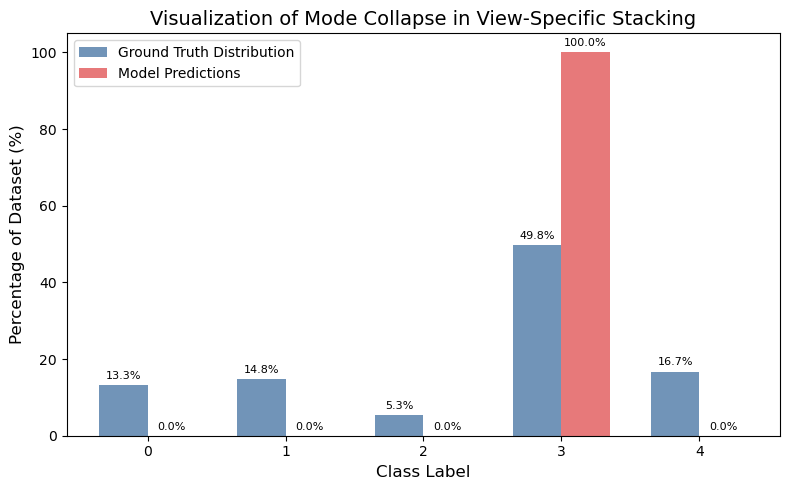

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# DATA FROM YOUR SCREENSHOTS
classes = ['0', '1', '2', '3', '4']
# "Support" column from your screenshot (True distribution)
ground_truth_counts = [35, 39, 14, 131, 44] 
# Based on your text "assigned nearly all mass to majority", 
# and Recall of 0.99 for class 3, we approximate the predictions:
predicted_counts = [0, 0, 0, 263, 0] # 263 is the total sum

# Calculate Percentages
total = sum(ground_truth_counts)
gt_pct = [x / total * 100 for x in ground_truth_counts]
pred_pct = [x / total * 100 for x in predicted_counts]

# PLOTTING
x = np.arange(len(classes))
width = 0.35  

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, gt_pct, width, label='Ground Truth Distribution', color='#4e79a7', alpha=0.8)
rects2 = ax.bar(x + width/2, pred_pct, width, label='Model Predictions', color='#e15759', alpha=0.8)

# LABELS
ax.set_ylabel('Percentage of Dataset (%)', fontsize=12)
ax.set_xlabel('Class Label', fontsize=12)
ax.set_title('Visualization of Mode Collapse in View-Specific Stacking', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

# Annotations (Optional)
ax.bar_label(rects1, padding=3, fmt='%.1f%%', fontsize=8)
ax.bar_label(rects2, padding=3, fmt='%.1f%%', fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\MBHS_PC\AppData\Local\Temp\ipykernel_12452\35595830.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Class', y='F1_Score', data=df, palette=colors)


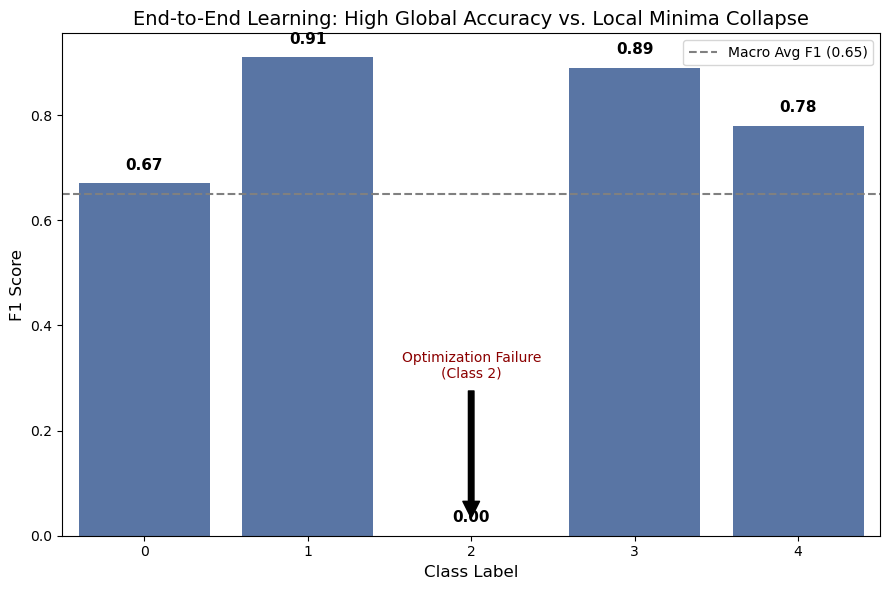

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data from Screenshot 2 (5-Class End-to-End)
data = {
    'Class': ['0', '1', '2', '3', '4'],
    'F1_Score': [0.67, 0.91, 0.00, 0.89, 0.78],
    'Support': [35, 39, 14, 131, 44] # Optional context
}
df = pd.DataFrame(data)

# Set up the plot
plt.figure(figsize=(9, 6))
colors = ['#4c72b0' if x > 0 else '#c44e52' for x in df['F1_Score']] # Blue for good, Red for 0.0

# Create Bar Plot
ax = sns.barplot(x='Class', y='F1_Score', data=df, palette=colors)

# Add value labels on top
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.02, 
            f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add "Average" Line to show the contrast
plt.axhline(y=0.65, color='grey', linestyle='--', label='Macro Avg F1 (0.65)')
plt.legend()

# Annotations matching your text
plt.title('End-to-End Learning: High Global Accuracy vs. Local Minima Collapse', fontsize=14)
plt.ylabel('F1 Score', fontsize=12)
plt.xlabel('Class Label', fontsize=12)

# Pointing out the failure
plt.annotate('Optimization Failure\n(Class 2)', 
             xy=(2, 0.02), 
             xytext=(2, 0.3),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='center', fontsize=10, color='darkred')

plt.tight_layout()
plt.show()